In [1]:
from t212_client import Trading212Client, Executor
from market_data import MarketData
from strategy import Signaller, plot_relation
from state_manager import StateManager
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from config import FileParams
import time
import logging

client = Trading212Client()
executor = Executor(client)
market = MarketData()
strategy = Signaller()
state_manager = StateManager()

def open_position(
        target_value: int,
        t212_ticker: str,
        current_price: float,
        timeout: int = 60
):
    
    logging.basicConfig(
        filename=Path("bot.log"),
        level=logging.INFO
        )

    opening_state = {
        "ticker": t212_ticker,
        "target_value": target_value,
        "position_quantity": target_value/current_price,
        "current_position_value": target_value
    }
    client.open_position(t212_ticker,target_value/current_price)
    logging.info(f"Opening position of {t212_ticker} at size {target_value/current_price} units priced at {current_price} per unit")

    filled_order = False
    start = time.time()

    while time.time() - start < timeout:
        print(f'\nChecking order fill: {round(time.time() - start,0)}/{timeout} seconds')

        new_quant = client.get_position_quantity(t212_ticker)

        if new_quant == 0:
            filled_order = True
            break

        time.sleep(5)

    if filled_order:

        state_manager.save_state(opening_state)

        logging.info("Position opened")
        print('Position Opened')
        return
    
    else:

        logging.info("Position unable to open")
        print('\nPosition unable to be opened')
        print('\nStopping bot...')
        bot_running = False
        return

In [2]:
open_position(
    target_value=1000,
    t212_ticker="QUBT_US_EQ",
    current_price=8.81
)

PAYLOAD: {'extendedHours': False, 'quantity': 113.51, 'ticker': 'QUBT_US_EQ'}
STATUS: 200
RESPONSE: {"id":51600218897,"strategy":"QUANTITY","type":"MARKET","ticker":"QUBT_US_EQ","quantity":113.51,"filledQuantity":0,"status":"NEW","currency":"GBP","extendedHours":false,"initiatedFrom":"API","side":"BUY","createdAt":"2026-07-08T17:08:57.322+03:00","instrument":{"ticker":"QUBT_US_EQ","name":"Quantum Computing","isin":"US74766W1080","currency":"USD"}}

Checking order fill: 0.0/60 seconds
Position Opened


In [5]:
from datetime import datetime

file_params: FileParams = {
    "period": "58d",
    "interval": "2m",
    "down_max": 10,
    "up_max": 15,
    "up_retrieval": False
}
start_date = "2026-05-05"
end_date = "2026-07-02"
print(str((datetime.strptime(end_date, "%Y-%m-%d") - (datetime.strptime(start_date, "%Y-%m-%d"))).days) + "d")

58d


In [3]:
# options for create_data:
    # period:
        # 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, max
    # interval:
        # 1m (only available for last 7 days), 2m, 5m, 15m, 30m, 60m, 90m, 1h
        # (intraday only availble for last 60 days), 1d, 5d, 1wk, 1mo, 3mo

strategy.create_data(
    period=file_params["period"],
    interval=file_params["interval"],
    down_max=file_params["down_max"],
    up_max=file_params["up_max"],
    up_retrieval=file_params["up_retrieval"],
    start_date=start_date,
    end_date=end_date
    )

  0%|          | 17/4999 [00:06<24:55,  3.33it/s]HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TRAD.R"}}}
$TRAD.R: possibly delisted; no timezone found
  2%|▏         | 90/4999 [00:37<39:55,  2.05it/s]  HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: EPR$C"}}}
$EPR$C: possibly delisted; no timezone found
100%|██████████| 4999/4999 [35:30<00:00,  2.35it/s]


{'both': {'up_pct': np.float64(0.17163730668212632), 'down_pct': np.float64(-0.0950245252207099)}, 'just_strat': {'up_pct': np.float64(0.11102564728074996), 'down_pct': np.float64(-0.07211119718906563)}}


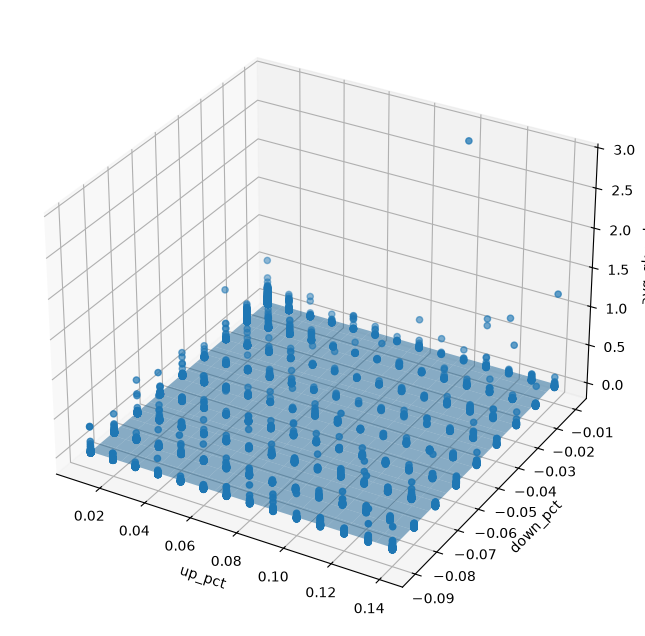

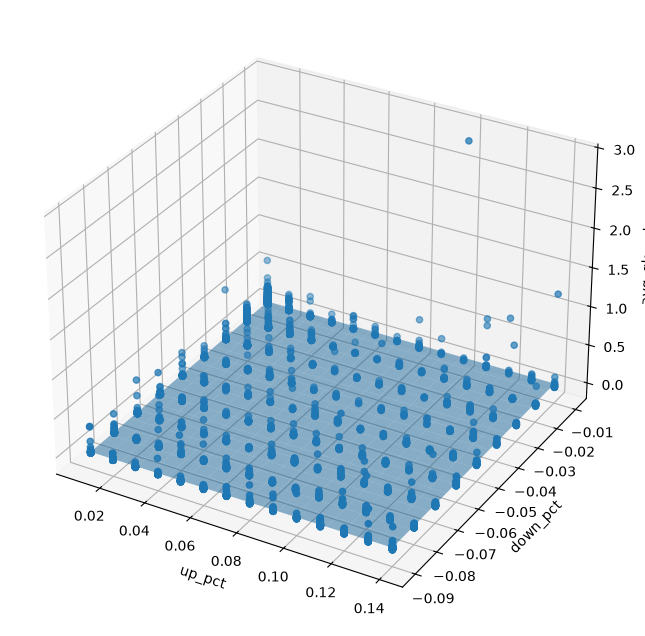

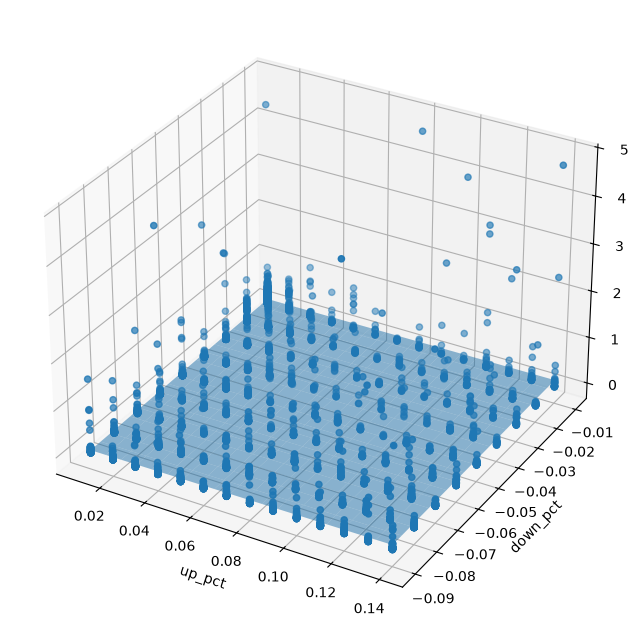

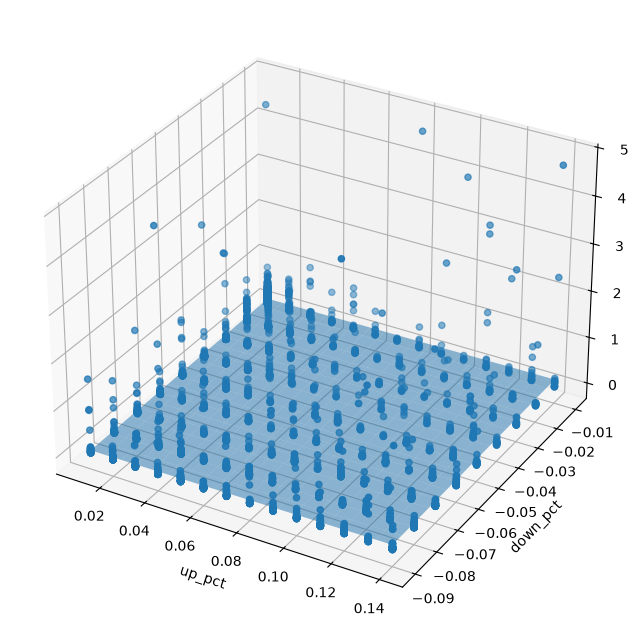

In [6]:
print(strategy.get_signal("QUBT",file_params))

In [7]:
RESULTS_FILE = Path(f"/Users/tristanwinter/Trading/csv_files/results_{file_params["period"]}_{file_params['interval']}_{file_params['up_max']}_{file_params['down_max']}_{file_params['up_retrieval']}.csv")

df = pd.read_csv(RESULTS_FILE)
df['hold_pct_pnl'] = df['hold_profit']/10
df['strat_pct_pnl'] = df['strat_profit']/10

df_strat = df.copy()
df_strat = df_strat[df_strat['better'] == 1]

In [8]:
print("Both:")
print("-----")
print(f"Max strat_pct_pnl: {df['strat_pct_pnl'].max()}")
print(f"Max hold_pct_pnl: {df['hold_pct_pnl'].max()}")
print("-----")
print(f"Mean strat_pct_pnl: {df['strat_pct_pnl'].mean()}")
print(f"Mean hold_pct_pnl: {df['hold_pct_pnl'].mean()}")
print("-----")
print(f"Median strat_pct_pnl: {df['strat_pct_pnl'].median()}")
print(f"Median hold_pct_pnl: {df['hold_pct_pnl'].median()}")
print("-----")
print(f"Std strat_pct_pnl: {df['strat_pct_pnl'].std()}")
print(f"Std hold_pct_pnl: {df['hold_pct_pnl'].std()}")
print("-----")
print(f"Min strat_pct_pnl: {df['strat_pct_pnl'].min()}")
print(f"Min hold_pct_pnl: {df['hold_pct_pnl'].min()}")

Both:
-----
Max strat_pct_pnl: 1367.944848059457
Max hold_pct_pnl: 4346.764449188205
-----
Mean strat_pct_pnl: 6.6194357484060555
Mean hold_pct_pnl: 2.2478310256270335
-----
Median strat_pct_pnl: 1.0222908089078544
Median hold_pct_pnl: 0.35105541250903793
-----
Std strat_pct_pnl: 45.042100981195425
Std hold_pct_pnl: 73.10708568547356
-----
Min strat_pct_pnl: -285.80839306604287
Min hold_pct_pnl: -99.71984088153488


In [22]:
print("Only strat:")
print("-----")
print(f"Max pct_pnl: {df_strat['strat_pct_pnl'].max()}")
print("-----")
print(f"Mean pct_pnl: {df_strat['strat_pct_pnl'].mean()}")
print("-----")
print(f"Median pct_pnl: {df_strat['strat_pct_pnl'].median()}")
print("-----")
print(f"Std pct_pnl: {df_strat['strat_pct_pnl'].std()}")
print("-----")
print(f"Min pct_pnl: {df_strat['strat_pct_pnl'].min()}")

Only strat:
-----
Max pct_pnl: 480.2431528346028
-----
Mean pct_pnl: 3.4903051929069524
-----
Median pct_pnl: 0.6764987016909118
-----
Std pct_pnl: 22.013640393490064
-----
Min pct_pnl: -68.52568168937226


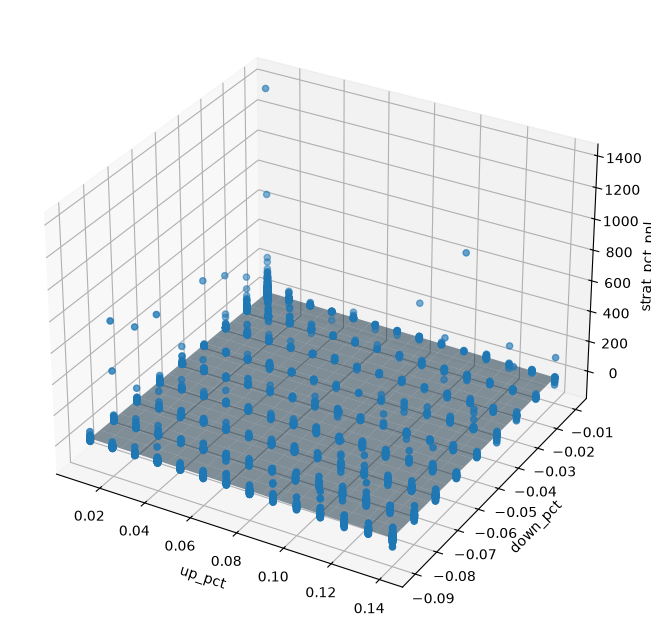

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[-137.76,-155.4 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.586
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[3.05,1.6 ]"


In [9]:
plot_relation(
    ["up_pct","down_pct","strat_pct_pnl"],
    df_strat,
    plot=True
)